# Importancia de la topología informacional de BTC

Análisis causal y reproducible de la utilidad de `BTC_y` como coordenada del simplex transaccional y como descriptor de regímenes futuros de volatilidad.

El notebook reproduce las etapas A–K del análisis exploratorio: dependencia lineal y no lineal, lags, heterocedasticidad, volatilidad futura, regresión, clasificación de tres y cinco regímenes y contrastes anidados de utilidad informacional.

**Contrato:** sin `shuffle`, features disponibles hasta `t`, targets posteriores a `t`, umbrales ajustados sólo en train, frontera train/test purgada y walk-forward expansivo con `gap` temporal.

## 1. Dependencias

Colab ya incluye NumPy, pandas, SciPy, scikit-learn y Matplotlib. Se aseguran únicamente los lectores Parquet y LightGBM.

In [ ]:
%pip install -q lightgbm pyarrow

## 2. Drive y configuración

- Dejá `RUN_PIPELINE=True` para estimar todo.
- Cambialo a `False` para leer resultados ya guardados sin volver a entrenar.
- `RUN_WALK_FORWARD=False` permite una primera prueba rápida sólo con holdout.

In [ ]:
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/Neural/NPP/Cripto')
PRICE_PATH = Path('/content/drive/MyDrive/0626p.parquet')
SIMPLEX_PATH = Path('/content/drive/MyDrive/0626dfyp.parquet')
OUTPUT_DIR = PROJECT_DIR / 'topologia_informacional_BTC'
DRIVE_SCRIPT = PROJECT_DIR / 'analisis_topologia_informacional_btc.py'

RUN_PIPELINE = True
RUN_WALK_FORWARD = True
BACKEND = 'lightgbm'  # 'lightgbm' o 'histgb'
SEED = 42
FOLDS = 5

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Resultados:', OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Resultados: /content/drive/MyDrive/Neural/NPP/Cripto/topologia_informacional_BTC


## 3. Motor científico versionado

Se utiliza primero la copia guardada junto al notebook en Drive. Si no existe, se descarga la versión exacta del commit científico publicado en GitHub.

In [ ]:
import urllib.request

PINNED_COMMIT = 'd62d9f4fb4f0aa26bdb9f3b9a1b00681c28983e3'
RAW_SCRIPT_URL = (
    'https://raw.githubusercontent.com/Miguithub/NPP/'
    f'{PINNED_COMMIT}/analisis_topologia_informacional_btc.py'
)
RUNTIME_SCRIPT = Path('/content/analisis_topologia_informacional_btc.py')

if DRIVE_SCRIPT.exists():
    RUNTIME_SCRIPT.write_bytes(DRIVE_SCRIPT.read_bytes())
    print('Motor cargado desde Drive:', DRIVE_SCRIPT)
else:
    urllib.request.urlretrieve(RAW_SCRIPT_URL, RUNTIME_SCRIPT)
    print('Motor descargado desde el commit:', PINNED_COMMIT)

assert RUNTIME_SCRIPT.stat().st_size > 10_000, 'El script descargado está incompleto.'

Motor cargado desde Drive: /content/drive/MyDrive/Neural/NPP/Cripto/analisis_topologia_informacional_btc.py


## 4. Ejecución completa o reanudación desde CSV

Esta celda estima el pipeline sólo cuando `RUN_PIPELINE=True`. Los resultados quedan persistidos inmediatamente en `OUTPUT_DIR`; en otra sesión podés poner el interruptor en `False` y continuar directamente con la lectura.

In [ ]:
import subprocess
import sys

if RUN_PIPELINE:
    command = [
        sys.executable, str(RUNTIME_SCRIPT),
        '--price-path', str(PRICE_PATH),
        '--simplex-path', str(SIMPLEX_PATH),
        '--output-dir', str(OUTPUT_DIR),
        '--backend', BACKEND,
        '--seed', str(SEED),
        '--folds', str(FOLDS),
    ]
    if not RUN_WALK_FORWARD:
        command.append('--skip-walk-forward')
    subprocess.run(command, check=True)
else:
    required = OUTPUT_DIR / '09c_clasificacion_train.csv'
    if not required.exists():
        raise FileNotFoundError(
            f'No hay resultados guardados en {OUTPUT_DIR}. Activá RUN_PIPELINE.'
        )
    print('Se reutilizan los resultados existentes; no se reentrena.')

## 5. Funciones de lectura

Cada CSV contiene columnas `experiment`, `model` y `feature_set` para que ninguna métrica quede separada del modelo que la produjo.

In [ ]:
import json
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

def load_result(name):
    path = OUTPUT_DIR / name
    if not path.exists():
        raise FileNotFoundError(path)
    if path.stat().st_size <= 2:
        return pd.DataFrame()
    return pd.read_csv(path)

print('Archivos disponibles:')
for path in sorted(OUTPUT_DIR.iterdir()):
    if path.is_file():
        print('-', path.name)

Archivos disponibles:
- 00_auditoria_datos.csv
- 01_dependencia_basica.csv
- 02_features_derivadas_vs_precio.csv
- 03_dBTC_y_vs_precio_retorno.csv
- 04_barrido_lags_retorno.csv
- 05_descomposicion_lag_4.csv
- 06_barrido_volatilidad_futura.csv
- 06b_estabilidad_mitades.csv
- 07_regresion_holdout.csv
- 07b_regresion_train.csv
- 08_regresion_walk_forward.csv
- 08b_regresion_walk_forward_train.csv
- 09_clasificacion_holdout.csv
- 09b_clasificacion_walk_forward.csv
- 09c_clasificacion_train.csv
- 09d_clasificacion_walk_forward_train.csv
- 10_clasificacion_por_clase_holdout.csv
- 10b_matrices_confusion_holdout.csv
- 10c_clasificacion_por_clase_walk_forward.csv
- 11_importancia_features_holdout.csv
- 12_thresholds_regimen.csv
- 13_utilidad_topologia.csv
- 14_resumen_utilidad_topologia.csv
- fig_01_mi_lag_horizonte.png
- fig_02_macro_f1_holdout.png
- fig_03_utilidad_incremental.png
- manifest.json


## 6. Auditoría de datos y split

Verifica rango temporal, observaciones inválidas, tamaño de train/test, purga y ausencia de shuffle.

In [ ]:
audit = load_result('00_auditoria_datos.csv')
display(audit)

,experiment,model,feature_set,rows_joined,missing_price,missing_BTC_y,nonpositive_price,BTC_y_outside_unit_interval,start,end,rows_model_frame,rows_train,rows_purged,rows_test,shuffle
0,input_audit,none,price+BTC_y,26064,0,0,0,0,2026-01-01 00:00:00+00:00,2026-06-30 23:50:00+00:00,26025,18215,2,7808,False


## 7. Etapas A–C — dependencia básica y tendencia compartida

Primero se comprueba si `BTC_y` se relaciona con el nivel de precio. La correlación parcial controla por el precio contemporáneo para detectar asociaciones generadas por persistencia o tendencia común.

In [ ]:
basic = load_result('01_dependencia_basica.csv')
derived = load_result('02_features_derivadas_vs_precio.csv')
display(basic)
display(derived.sort_values('mutual_information', ascending=False))

,experiment,model,feature_set,feature,target,sample,n,pearson,spearman,mutual_information
0,A_contemporaneous,nonparametric_dependency,BTC_y,BTC_y,price_t,development_train,18253,-0.033767,-0.069184,0.061582
1,B_price_t_plus_1,nonparametric_dependency,BTC_y,BTC_y,price_t_plus_1,development_train,18252,-0.033727,-0.069031,0.060254


,experiment,model,feature_set,feature,target,sample,n,pearson,spearman,mutual_information,partial_corr_controlling_price_t
7,B1_derived_vs_next_price,nonparametric_dependency,macd_y_1m_3m,macd_y_1m_3m,price_t_plus_1,development_train,6125,-3.409449e-01,-0.505821,2.087142,-0.001018
6,B1_derived_vs_next_price,nonparametric_dependency,macd_y_1w_1m,macd_y_1w_1m,price_t_plus_1,development_train,14221,-2.087511e-01,-0.203170,1.290152,0.004888
4,B1_derived_vs_next_price,nonparametric_dependency,shannon_surprisal,shannon_surprisal,price_t_plus_1,development_train,18252,2.524316e-02,0.069031,0.062371,-0.002331
5,B1_derived_vs_next_price,nonparametric_dependency,logit_BTC_y,logit_BTC_y,price_t_plus_1,development_train,18252,-2.809744e-02,-0.069031,0.061670,0.001846
0,B1_derived_vs_next_price,nonparametric_dependency,BTC_y,BTC_y,price_t_plus_1,development_train,18252,-3.372676e-02,-0.069031,0.060254,0.001038
3,B1_derived_vs_next_price,nonparametric_dependency,dlog_BTC_y,dlog_BTC_y,price_t_plus_1,development_train,18251,5.485130e-07,0.000025,0.016257,0.004395
1,B1_derived_vs_next_price,nonparametric_dependency,dBTC_y,dBTC_y,price_t_plus_1,development_train,18251,4.156005e-05,0.000198,0.015500,0.005231
2,B1_derived_vs_next_price,nonparametric_dependency,abs_dBTC_y,abs_dBTC_y,price_t_plus_1,development_train,18251,-1.198157e-01,-0.088475,0.011288,-0.009487


In [39]:
# Objetivo de las etapas A–C
# - Etapa A: comprobar si BTC_y se relaciona contemporáneamente con el precio de Bitcoin.
# - Etapa B: comprobar si BTC_y(t) se relaciona con el precio de la barra siguiente, P(t+1).
# - Etapa C: probar diferentes transformaciones de BTC_y y verificar si la asociación con P(t+1) sobrevive después de controlar por P(t).
# La pregunta decisiva es:
# ¿La topología contiene información nueva sobre el futuro o simplemente coincide con estados persistentes del precio ya observables en el presente?


############################################################################


# La sección 7 no demuestra que los MACD topológicos pronostiquen el precio. Demuestra que están fuertemente asociados con su estado histórico de baja frecuencia.
# La evidencia conjunta sugiere:
# - BTC_y no explica significativamente el precio contemporáneo de manera lineal.
# - Mover el target de \(P_t\) a \(P_{t+1}\) no genera nueva información aparente.
# - Las transformaciones instantáneas no añaden señal.
# - Los MACD topológicos detectan regímenes compartidos muy fuertes.
# - Esa asociación desaparece prácticamente al controlar por el precio actual.
# - Por tanto, BTC_y parece más prometedora como descriptor de estado, régimen o variable de gating que como regresor directo del precio.
# Para comprobar definitivamente la hipótesis de las filas 6 y 7, el contraste correcto sería estimar:
# \[
# I(MACD_t;P_{t+1}\mid P_t)
# \]y compararlo contra un nulo obtenido mediante permutaciones por bloques o desplazamientos temporales circulares. Ese experimento separaría dependencia temporal compartida de información predictiva verdaderamente incremental.

## 8. Etapas D–F — cambios, lags y naturaleza de la señal

Se distingue si `ΔBTC_y` informa dirección, magnitud, colas o varianza condicional. Una AUC cercana a 0.5 descarta dirección; una caída de MI al estandarizar por volatilidad apunta a información de régimen.

In [ ]:
relations = load_result('03_dBTC_y_vs_precio_retorno.csv')
lag_scan = load_result('04_barrido_lags_retorno.csv')
lag_decomposition = load_result('05_descomposicion_lag_4.csv')
display(relations)
display(lag_scan.sort_values('mutual_information', ascending=False).head(10))
display(lag_decomposition)

,experiment,model,feature_set,feature,target,sample,n,pearson,spearman,mutual_information
0,D_dBTC_y_relations,nonparametric_dependency,dBTC_y_lag_0,dBTC_y_lag_0,price_t,development_train,18252,-0.000064,-0.000015,0.016548
1,D_dBTC_y_relations,nonparametric_dependency,dBTC_y_lag_0,dBTC_y_lag_0,delta_price_t,development_train,18252,-0.001862,-0.002403,0.007206
2,D_dBTC_y_relations,nonparametric_dependency,dBTC_y_lag_0,dBTC_y_lag_0,return_t,development_train,18252,-0.002947,-0.003238,0.012610
3,D_dBTC_y_relations,nonparametric_dependency,dBTC_y_lag_1,dBTC_y_lag_1,price_t,development_train,18251,0.000042,0.000198,0.015500
4,D_dBTC_y_relations,nonparametric_dependency,dBTC_y_lag_1,dBTC_y_lag_1,delta_price_t,development_train,18251,0.005231,0.007392,0.000772
5,D_dBTC_y_relations,nonparametric_dependency,dBTC_y_lag_1,dBTC_y_lag_1,return_t,development_train,18251,0.005352,0.007787,0.000000


,experiment,model,feature_set,feature,target,sample,n,pearson,spearman,mutual_information,lag,is_predictive
10,E_return_lag_scan,nonparametric_dependency,dBTC_y_lag_10,dBTC_y_lag_10,return_t,development_train,18242,-0.001068,-0.005190,0.016915,10,True
4,E_return_lag_scan,nonparametric_dependency,dBTC_y_lag_4,dBTC_y_lag_4,return_t,development_train,18248,-0.001062,-0.002622,0.013841,4,True
18,E_return_lag_scan,nonparametric_dependency,dBTC_y_lag_18,dBTC_y_lag_18,return_t,development_train,18234,-0.010930,-0.000421,0.013556,18,True
0,E_return_lag_scan,nonparametric_dependency,dBTC_y_lag_0,dBTC_y_lag_0,return_t,development_train,18252,-0.002947,-0.003238,0.012610,0,False
13,E_return_lag_scan,nonparametric_dependency,dBTC_y_lag_13,dBTC_y_lag_13,return_t,development_train,18239,0.010243,0.004829,0.009592,13,True
3,E_return_lag_scan,nonparametric_dependency,dBTC_y_lag_3,dBTC_y_lag_3,return_t,development_train,18249,-0.002115,-0.002880,0.007983,3,True
11,E_return_lag_scan,nonparametric_dependency,dBTC_y_lag_11,dBTC_y_lag_11,return_t,development_train,18241,0.001605,-0.000062,0.007008,11,True
15,E_return_lag_scan,nonparametric_dependency,dBTC_y_lag_15,dBTC_y_lag_15,return_t,development_train,18237,-0.002522,-0.002262,0.004526,15,True
7,E_return_lag_scan,nonparametric_dependency,dBTC_y_lag_7,dBTC_y_lag_7,return_t,development_train,18245,-0.000035,-0.009086,0.004129,7,True
5,E_return_lag_scan,nonparametric_dependency,dBTC_y_lag_5,dBTC_y_lag_5,return_t,development_train,18247,0.004318,0.003275,0.002762,5,True


,experiment,model,feature_set,target,sample,n,mutual_information,auc_orientation_free,feature,pearson,spearman,threshold_fitted_on_train,levene_statistic,levene_pvalue,minimum_group_std,maximum_group_std,std_ratio_max_min,mi_raw_return,mi_volatility_standardized_return
0,F1_direction,dependency_lag_decomposition,dBTC_y_lag_4,return_direction,development_train,18248,0.000000,0.500161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F2_magnitude,nonparametric_dependency,dBTC_y_lag_4,abs_return,development_train,18248,0.007705,NaN,dBTC_y_lag_4,0.001984,0.0101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F3_tails,dependency_lag_decomposition,dBTC_y_lag_4,abs_return_top_10pct,development_train,18248,0.000000,NaN,NaN,NaN,NaN,0.003113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F3_tails,dependency_lag_decomposition,dBTC_y_lag_4,abs_return_top_5pct,development_train,18248,0.002952,NaN,NaN,NaN,NaN,0.004423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F3_tails,dependency_lag_decomposition,dBTC_y_lag_4,abs_return_top_2.5pct,development_train,18248,0.000969,NaN,NaN,NaN,NaN,0.005877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,F3_tails,dependency_lag_decomposition,dBTC_y_lag_4,abs_return_top_1pct,development_train,18248,0.000466,NaN,NaN,NaN,NaN,0.008280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,F4_conditional_variance,levene_deciles,dBTC_y_lag_4,return_variance,development_train,18248,NaN,NaN,NaN,NaN,NaN,NaN,2.790141,0.002864,0.001918,0.002486,1.296257,0.013841,0.000854


In [ ]:
# No hay evidencia de dirección.
# No hay relación útil con el retorno esperado.
# No hay clasificación consistente de las colas.
# La dependencia pequeña detectada parece provenir principalmente de diferencias en la varianza condicional.
# BTC_y vuelve a comportarse más como indicador del estado de volatilidad del sistema que como predictor directo del movimiento de Bitcoin.

## 9. Etapa G — topología y volatilidad futura

El barrido lag × horizonte se calcula sólo sobre desarrollo. La estabilidad entre mitades permite detectar un pico aislado que no se repite temporalmente.

,experiment,model,feature_set,feature,target,sample,n,pearson,spearman,mutual_information,horizon,lag,is_predictive
3,G_future_volatility_scan,nonparametric_dependency,dBTC_y_lag_3,dBTC_y_lag_3,future_rms_h1,development_train,18248,0.001984,0.010100,0.007705,1,3,True
14,G_future_volatility_scan,nonparametric_dependency,dBTC_y_lag_14,dBTC_y_lag_14,future_rms_h1,development_train,18237,-0.000151,0.003817,0.006542,1,14,True
16,G_future_volatility_scan,nonparametric_dependency,dBTC_y_lag_16,dBTC_y_lag_16,future_rms_h1,development_train,18235,0.002038,0.001752,0.004726,1,16,True
34,G_future_volatility_scan,nonparametric_dependency,dBTC_y_lag_13,dBTC_y_lag_13,future_rms_h2,development_train,18238,0.005391,0.005882,0.010000,2,13,True
41,G_future_volatility_scan,nonparametric_dependency,dBTC_y_lag_20,dBTC_y_lag_20,future_rms_h2,development_train,18231,0.006445,0.005719,0.008987,2,20,True
27,G_future_volatility_scan,nonparametric_dependency,dBTC_y_lag_6,dBTC_y_lag_6,future_rms_h2,development_train,18245,0.009050,0.009747,0.007788,2,6,True
52,G_future_volatility_scan,nonparametric_dependency,dBTC_y_lag_10,dBTC_y_lag_10,future_rms_h3,development_train,18241,-0.003717,0.007977,0.010204,3,10,True
61,G_future_volatility_scan,nonparametric_dependency,dBTC_y_lag_19,dBTC_y_lag_19,future_rms_h3,development_train,18232,0.006836,0.005693,0.008100,3,19,True
55,G_future_volatility_scan,nonparametric_dependency,dBTC_y_lag_13,dBTC_y_lag_13,future_rms_h3,development_train,18238,0.007097,0.009429,0.006201,3,13,True
67,G_future_volatility_scan,nonparametric_dependency,dBTC_y_lag_4,dBTC_y_lag_4,future_rms_h6,development_train,18247,0.008701,0.010085,0.008553,6,4,True


,experiment,model,feature_set,feature,target,sample,n,pearson,spearman,mutual_information
0,G_stability_halves,nonparametric_dependency,dBTC_y_lag_0,dBTC_y_lag_0,future_rms_h2,first_half,9124,0.001880,0.001085,0.011434
1,G_stability_halves,nonparametric_dependency,dBTC_y_lag_0,dBTC_y_lag_0,future_rms_h2,second_half,9126,0.018634,0.010614,0.010033


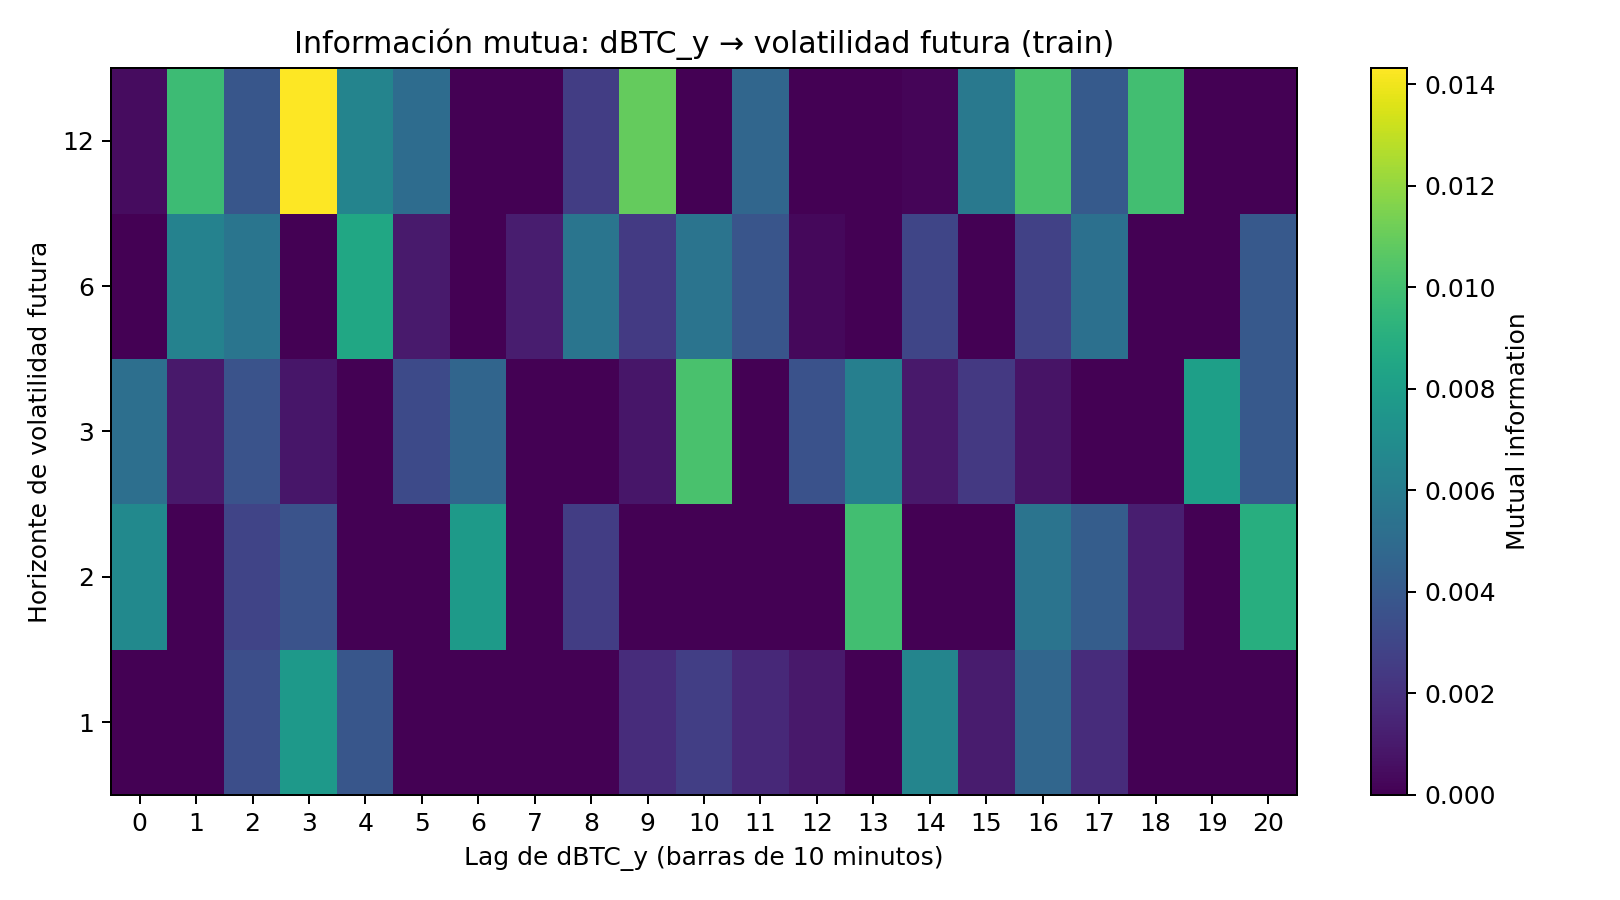

In [ ]:
future_vol = load_result('06_barrido_volatilidad_futura.csv')
halves = load_result('06b_estabilidad_mitades.csv')
display(
    future_vol.sort_values(['horizon', 'mutual_information'], ascending=[True, False])
    .groupby('horizon', as_index=False).head(3)
)
display(halves)
display(Image(filename=str(OUTPUT_DIR / 'fig_01_mi_lag_horizonte.png')))

In [ ]:
# ¿Los cambios en la topología de BTC contienen información anticipada sobre la
# volatilidad futura, aunque no predigan dirección ni retorno?



# Los cambios en BTC_y presentan una dependencia no lineal pequeña y parcialmente estable con la volatilidad futura.
# Sin embargo, la ausencia de una estructura lag–horizonte persistente y la magnitud reducida de las asociaciones
# impiden interpretar el barrido como evidencia de capacidad predictiva autónoma. El resultado justifica evaluar
# BTC_y como información incremental junto con la volatilidad pasada, que es precisamente el objetivo de la etapa H.





# La etapa G aporta evidencia débil pero no completamente nula:
# 1. No existe una relación lineal relevante.
# 2. La MI es pequeña en todos los horizontes.
# 3. Los máximos cambian de lag y parecen aislados.
# 4. El mejor valor puede estar afectado por búsqueda múltiple.
# 5. Una dependencia pequeña se repite en ambas mitades para lag 0 y horizonte 2.
# 6. La topología puede funcionar mejor como descriptor de regiones o regímenes que como regresor univariado de volatilidad.


# En F observamos:
# - MI del retorno crudo: 0.01384;
# - MI del retorno estandarizado por volatilidad: 0.000854;
# - diferencias de casi 30% en la desviación estándar entre deciles de dBTC_y;
# - Levene significativo.
# Eso sugería una relación con el estado de volatilidad.
# La etapa G es compatible con esa lectura, pero la matiza:
# La topología parece relacionarse débilmente con estados de varianza, pero no aparece como un predictor univariado fuerte ni con un lag universal.

# Es decir, F encuentra heterogeneidad entre regiones topológicas; G muestra que convertir esa heterogeneidad en una predicción puntual de volatilidad futura no es sencillo.

## 10. Etapa H — regresión directa de volatilidad

Compara persistencia, regresión lineal y boosting con y sin `ΔBTC_y`. Si la mejora es prácticamente cero, la variable no debe venderse como regresor puntual aunque sí pueda servir como gate.

In [ ]:
reg_train = load_result('07b_regresion_train.csv')
reg_holdout = load_result('07_regresion_holdout.csv')
reg_walk_train = load_result('08b_regresion_walk_forward_train.csv')
reg_walk = load_result('08_regresion_walk_forward.csv')
print('TRAIN')
display(reg_train.sort_values('RMSE'))
print('HOLDOUT')
display(reg_holdout.sort_values('RMSE'))
if not reg_walk.empty:
    display(
        reg_walk.groupby(['model', 'feature_set'])[['MAE', 'RMSE', 'R2']]
        .agg(['mean', 'std'])
    )

TRAIN


,experiment,model,model_family,feature_set,split,n_train,n_eval,MAE,RMSE,R2
2,H_regression_holdout_train,linear_volatility_plus_topology,regression,sigma_past+dBTC_y,holdout_train,18215,18215,0.000912,0.001428,0.165773
1,H_regression_holdout_train,linear_volatility,regression,sigma_past,holdout_train,18215,18215,0.000912,0.001428,0.165757
4,H_regression_holdout_train,histgb_volatility_plus_topology,regression,sigma_past+dBTC_y,holdout_train,18215,18215,0.000958,0.001489,0.092650
3,H_regression_holdout_train,histgb_volatility,regression,sigma_past,holdout_train,18215,18215,0.000958,0.001490,0.090774
0,H_regression_holdout_train,persistence,regression,sigma_past,holdout_train,18215,18215,0.001057,0.001702,-0.185763


HOLDOUT


,experiment,model,model_family,feature_set,split,n_train,n_eval,MAE,RMSE,R2
2,H_regression_holdout,linear_volatility_plus_topology,regression,sigma_past+dBTC_y,holdout,18215,7808,0.000820,0.001191,0.162041
1,H_regression_holdout,linear_volatility,regression,sigma_past,holdout,18215,7808,0.000820,0.001191,0.161929
3,H_regression_holdout,histgb_volatility,regression,sigma_past,holdout,18215,7808,0.000887,0.001250,0.076494
4,H_regression_holdout,histgb_volatility_plus_topology,regression,sigma_past+dBTC_y,holdout,18215,7808,0.000887,0.001250,0.075768
0,H_regression_holdout,persistence,regression,sigma_past,holdout,18215,7808,0.000906,0.001411,-0.177636


MAE            \
                                                       mean       std   
model                           feature_set                             
histgb_volatility               sigma_past         0.001026  0.000158   
histgb_volatility_plus_topology sigma_past+dBTC_y  0.001021  0.000156   
linear_volatility               sigma_past         0.000976  0.000184   
linear_volatility_plus_topology sigma_past+dBTC_y  0.000976  0.000184   
persistence                     sigma_past         0.001120  0.000256   

                                                       RMSE            \
                                                       mean       std   
model                           feature_set                             
histgb_volatility               sigma_past         0.001531  0.000425   
histgb_volatility_plus_topology sigma_past+dBTC_y  0.001531  0.000424   
linear_volatility               sigma_past         0.001491  0.000409   
linear_volatility_plus_topology sigma_past+dBTC_y  0.001491  0.000409   
persistence                     sigma_past         0.001747  0.000402   

                                                         R2            
                                                       mean       std  
model                           feature_set                            
histgb_volatility               sigma_past        -0.028953  0.092015  
histgb_volatility_plus_topology sigma_past+dBTC_y -0.029403  0.093050  
linear_volatility               sigma_past         0.025014  0.079250  
linear_volatility_plus_topology sigma_past+dBTC_y  0.024793  0.079554  
persistence                     sigma_past        -0.374382  0.244401

In [ ]:
# La etapa H demuestra:
# 1. La volatilidad pasada sí contiene información predictiva.
# 2. Una regresión lineal sencilla es el mejor modelo.
# 3. El boosting no agrega valor frente a la relación lineal.
# 4. dBTC_y por sí sola no mejora materialmente la regresión.
# 5. La pequeña ganancia del holdout lineal no se sostiene en walk-forward.
# 6. La topología parece más útil para identificar estados o regímenes que para corregir directamente una predicción puntual de volatilidad.
# Esto no rechaza la utilidad de la topología informacional. Rechaza una formulación mucho más concreta:
# La primera diferencia aislada de BTC_y, incorporada aditivamente a un regresor de volatilidad, no tiene poder incremental relevante.

## 11. Etapas I–J — clasificación de regímenes

Se comparan 3 regímenes, 5 regímenes con 4.5% en cada cola extrema y 5 quintiles libres. Macro-F1 y balanced accuracy son las métricas principales; accuracy sola puede ocultar el colapso de clases minoritarias.

TRAIN


,regime_scheme,model,feature_set,accuracy,balanced_accuracy,macro_f1,log_loss
6,3_regimes,lightgbm_volatility_plus_topology,advanced_combined,0.627121,0.627116,0.626375,0.836412
4,3_regimes,lightgbm_volatility_multiscale,advanced_volatility,0.589020,0.589015,0.587919,0.865180
5,3_regimes,lightgbm_topology_multiscale,advanced_topology,0.581444,0.581438,0.578659,0.943660
3,3_regimes,tree_volatility_plus_topology,simple_combined,0.470107,0.470099,0.465128,1.018168
1,3_regimes,tree_volatility,simple_volatility,0.465056,0.465047,0.456849,1.024043
2,3_regimes,tree_topology,simple_topology,0.420917,0.420904,0.402023,1.069309
0,3_regimes,dummy_most_frequent,dummy,0.333352,0.333333,0.166674,24.028443
13,5_extreme_4_5,lightgbm_volatility_plus_topology,advanced_combined,0.598133,0.478301,0.520874,0.974564
11,5_extreme_4_5,lightgbm_volatility_multiscale,advanced_volatility,0.553006,0.420298,0.448268,1.029043
12,5_extreme_4_5,lightgbm_topology_multiscale,advanced_topology,0.559319,0.411583,0.433211,1.103696


HOLDOUT


,regime_scheme,model,feature_set,accuracy,balanced_accuracy,macro_f1,log_loss
6,3_regimes,lightgbm_volatility_plus_topology,advanced_combined,0.512295,0.511870,0.505532,0.967205
4,3_regimes,lightgbm_volatility_multiscale,advanced_volatility,0.505379,0.505225,0.501723,0.970973
3,3_regimes,tree_volatility_plus_topology,simple_combined,0.471055,0.465973,0.461873,1.020539
1,3_regimes,tree_volatility,simple_volatility,0.459016,0.452771,0.444597,1.024964
5,3_regimes,lightgbm_topology_multiscale,advanced_topology,0.460169,0.444324,0.428693,1.052158
2,3_regimes,tree_topology,simple_topology,0.430584,0.418443,0.399075,1.055513
0,3_regimes,dummy_most_frequent,dummy,0.381404,0.333333,0.184066,22.296471
11,5_extreme_4_5,lightgbm_volatility_multiscale,advanced_volatility,0.443648,0.294750,0.282028,1.223863
13,5_extreme_4_5,lightgbm_volatility_plus_topology,advanced_combined,0.443776,0.294090,0.278778,1.227082
10,5_extreme_4_5,tree_volatility_plus_topology,simple_combined,0.416752,0.271648,0.258539,1.280405


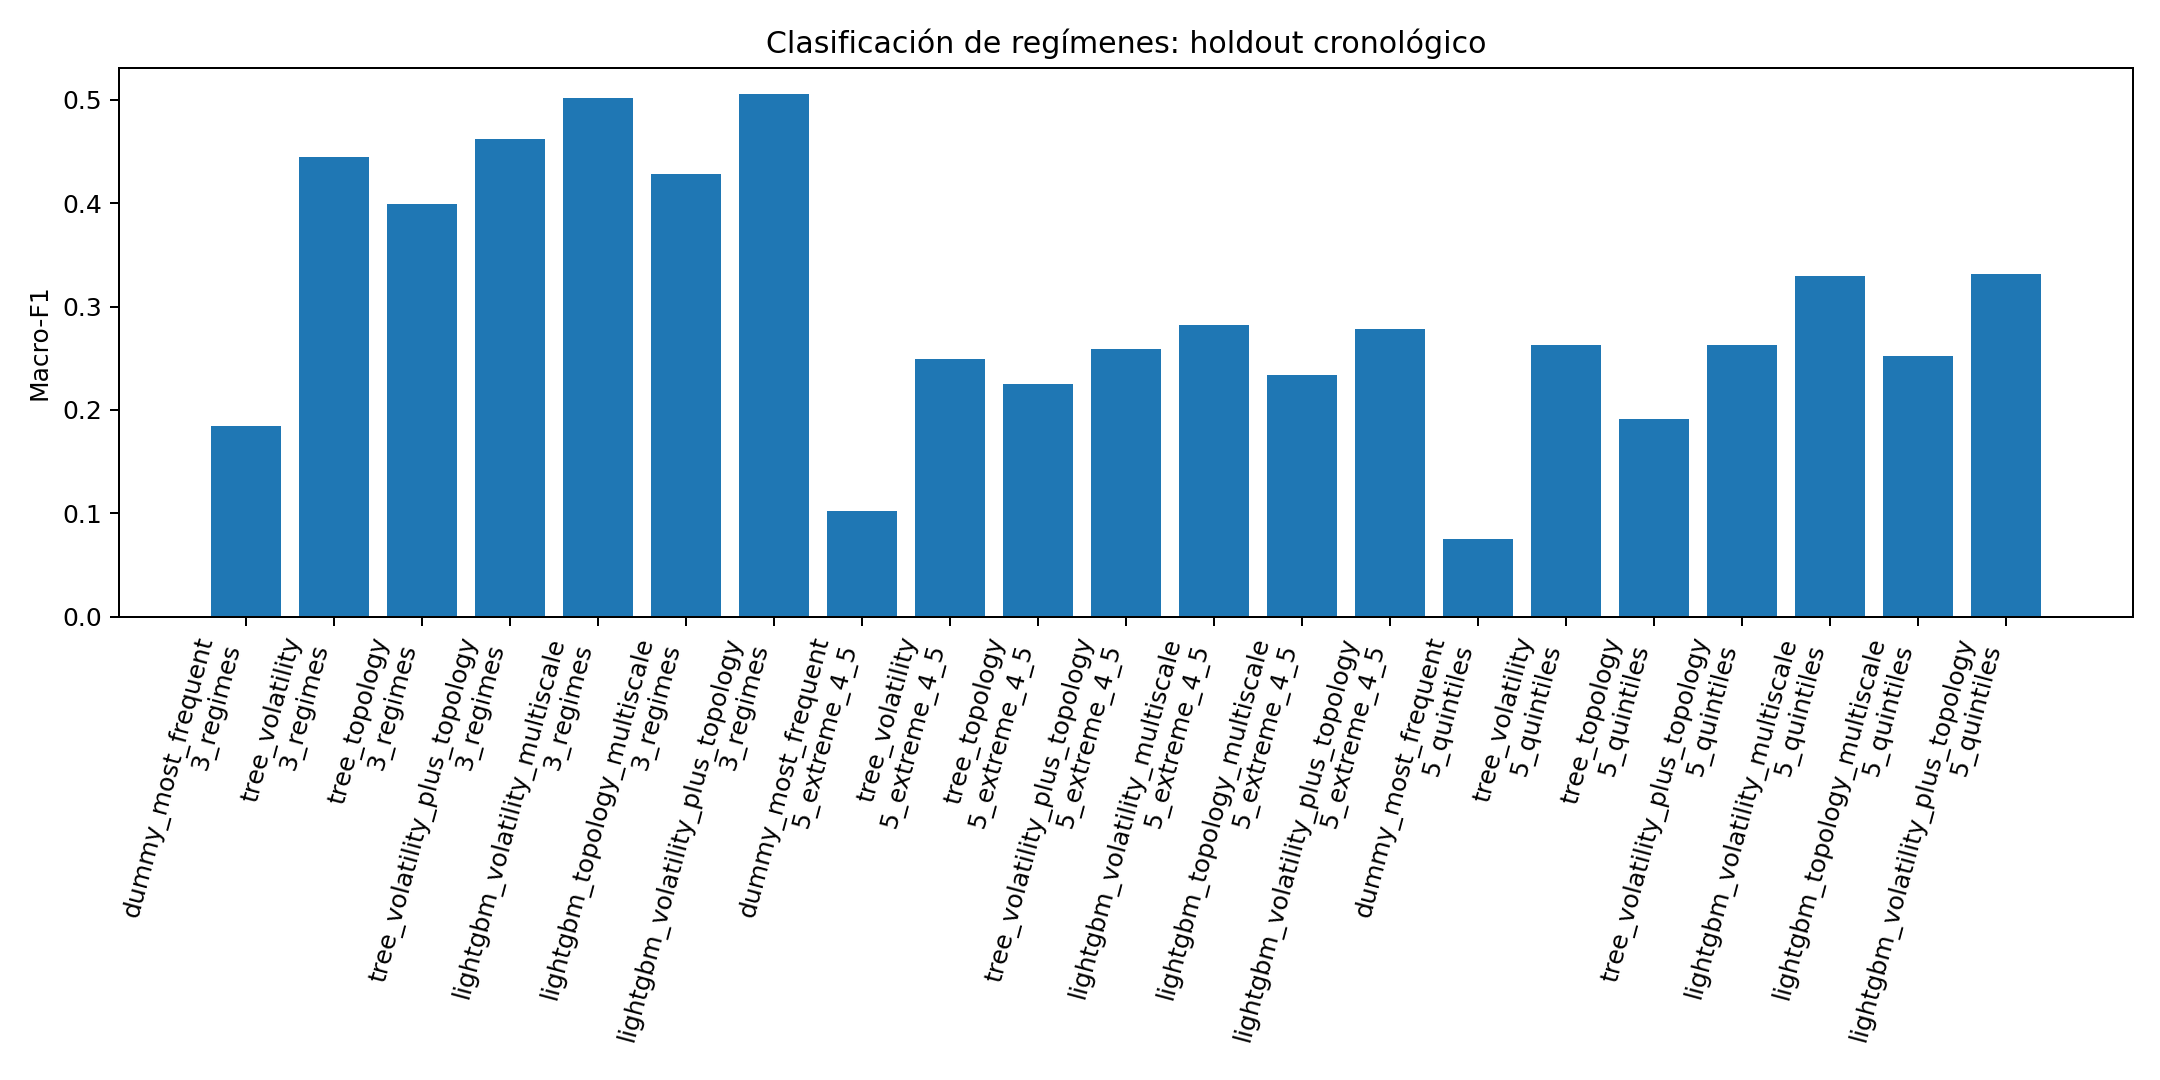

In [ ]:
classification_train = load_result('09c_clasificacion_train.csv')
classification = load_result('09_clasificacion_holdout.csv')
print('TRAIN')
display(
    classification_train.sort_values(['regime_scheme', 'macro_f1'], ascending=[True, False])
    [['regime_scheme', 'model', 'feature_set', 'accuracy',
      'balanced_accuracy', 'macro_f1', 'log_loss']]
)
print('HOLDOUT')
display(
    classification.sort_values(['regime_scheme', 'macro_f1'], ascending=[True, False])
    [['regime_scheme', 'model', 'feature_set', 'accuracy',
      'balanced_accuracy', 'macro_f1', 'log_loss']]
)
display(Image(filename=str(OUTPUT_DIR / 'fig_02_macro_f1_holdout.png')))

## 12. Recall y F1 por régimen

Esta tabla revela si un promedio aparentemente bueno se obtuvo sin identificar los estados extremos.

In [ ]:
by_class = load_result('10_clasificacion_por_clase_holdout.csv')
display(
    by_class.sort_values(['regime_scheme', 'model', 'class_id'])
    [['regime_scheme', 'model', 'feature_set', 'class_name',
      'precision', 'recall', 'f1', 'support']]
)

,regime_scheme,model,feature_set,class_name,precision,recall,f1,support
0,3_regimes,dummy_most_frequent,dummy,LOW,0.381404,1.000000,0.552197,2978
1,3_regimes,dummy_most_frequent,dummy,MID,0.000000,0.000000,0.000000,2643
2,3_regimes,dummy_most_frequent,dummy,HIGH,0.000000,0.000000,0.000000,2187
15,3_regimes,lightgbm_topology_multiscale,advanced_topology,LOW,0.473938,0.726662,0.573701,2978
16,3_regimes,lightgbm_topology_multiscale,advanced_topology,MID,0.393540,0.225880,0.287019,2643
17,3_regimes,lightgbm_topology_multiscale,advanced_topology,HIGH,0.482319,0.380430,0.425358,2187
12,3_regimes,lightgbm_volatility_multiscale,advanced_volatility,LOW,0.561965,0.595366,0.578184,2978
13,3_regimes,lightgbm_volatility_multiscale,advanced_volatility,MID,0.392812,0.351495,0.371006,2643
14,3_regimes,lightgbm_volatility_multiscale,advanced_volatility,HIGH,0.543706,0.568816,0.555978,2187
18,3_regimes,lightgbm_volatility_plus_topology,advanced_combined,LOW,0.568259,0.619208,0.592640,2978


## 13. Validación walk-forward

La media resume desempeño, pero el conteo de folds ganados muestra consistencia. Semillas y folds responden preguntas distintas: los folds prueban estabilidad temporal.

In [ ]:
walk_train = load_result('09d_clasificacion_walk_forward_train.csv')
walk = load_result('09b_clasificacion_walk_forward.csv')
if walk.empty:
    print('Walk-forward desactivado. Activá RUN_WALK_FORWARD y volvé a ejecutar el pipeline.')
else:
    walk_summary = (
        walk.groupby(['regime_scheme', 'model', 'feature_set'])
        [['balanced_accuracy', 'macro_f1', 'log_loss']]
        .agg(['mean', 'std'])
    )
    walk_train_summary = (
        walk_train.groupby(['regime_scheme', 'model', 'feature_set'])
        [['balanced_accuracy', 'macro_f1', 'log_loss']]
        .agg(['mean', 'std'])
    )
    print('TRAIN POR FOLD')
    display(walk_train_summary)
    print('VALIDACIÓN POR FOLD')
    display(walk_summary)

TRAIN POR FOLD


balanced_accuracy  \
                                                                                 mean   
regime_scheme model                             feature_set                             
3_regimes     dummy_most_frequent               dummy                        0.333333   
              lightgbm_topology_multiscale      advanced_topology            0.708296   
              lightgbm_volatility_multiscale    advanced_volatility          0.690954   
              lightgbm_volatility_plus_topology advanced_combined            0.749153   
              tree_topology                     simple_topology              0.435468   
              tree_volatility                   simple_volatility            0.489059   
              tree_volatility_plus_topology     simple_combined              0.496590   
5_extreme_4_5 dummy_most_frequent               dummy                        0.200000   
              lightgbm_topology_multiscale      advanced_topology            0.643409   
              lightgbm_volatility_multiscale    advanced_volatility          0.600369   
              lightgbm_volatility_plus_topology advanced_combined            0.712034   
              tree_topology                     simple_topology              0.255541   
              tree_volatility                   simple_volatility            0.282570   
              tree_volatility_plus_topology     simple_combined              0.288035   
5_quintiles   dummy_most_frequent               dummy                        0.200000   
              lightgbm_topology_multiscale      advanced_topology            0.709840   
              lightgbm_volatility_multiscale    advanced_volatility          0.649207   
              lightgbm_volatility_plus_topology advanced_combined            0.748413   
              tree_topology                     simple_topology              0.280042   
              tree_volatility                   simple_volatility            0.328278   
              tree_volatility_plus_topology     simple_combined              0.333476   

                                                                               \
                                                                          std   
regime_scheme model                             feature_set                     
3_regimes     dummy_most_frequent               dummy                0.000000   
              lightgbm_topology_multiscale      advanced_topology    0.109871   
              lightgbm_volatility_multiscale    advanced_volatility  0.089453   
              lightgbm_volatility_plus_topology advanced_combined    0.102403   
              tree_topology                     simple_topology      0.021041   
              tree_volatility                   simple_volatility    0.021198   
              tree_volatility_plus_topology     simple_combined      0.023799   
5_extreme_4_5 dummy_most_frequent               dummy                0.000000   
              lightgbm_topology_multiscale      advanced_topology    0.193353   
              lightgbm_volatility_multiscale    advanced_volatility  0.168402   
              lightgbm_volatility_plus_topology advanced_combined    0.180297   
              tree_topology                     simple_topology      0.013971   
              tree_volatility                   simple_volatility    0.012158   
              tree_volatility_plus_topology     simple_combined      0.014982   
5_quintiles   dummy_most_frequent               dummy                0.000000   
              lightgbm_topology_multiscale      advanced_topology    0.142800   
              lightgbm_volatility_multiscale    advanced_volatility  0.132404   
              lightgbm_volatility_plus_topology advanced_combined    0.141407   
              tree_topology                     simple_topology      0.013924   
              tree_volatility                   simple_volatility    0.017544   
              tree_volatility_plus_topology     simple_combined     

VALIDACIÓN POR FOLD


balanced_accuracy  \
                                                                                 mean   
regime_scheme model                             feature_set                             
3_regimes     dummy_most_frequent               dummy                        0.333333   
              lightgbm_topology_multiscale      advanced_topology            0.397906   
              lightgbm_volatility_multiscale    advanced_volatility          0.463881   
              lightgbm_volatility_plus_topology advanced_combined            0.469870   
              tree_topology                     simple_topology              0.390560   
              tree_volatility                   simple_volatility            0.431968   
              tree_volatility_plus_topology     simple_combined              0.433951   
5_extreme_4_5 dummy_most_frequent               dummy                        0.200000   
              lightgbm_topology_multiscale      advanced_topology            0.231951   
              lightgbm_volatility_multiscale    advanced_volatility          0.269301   
              lightgbm_volatility_plus_topology advanced_combined            0.272449   
              tree_topology                     simple_topology              0.230135   
              tree_volatility                   simple_volatility            0.248537   
              tree_volatility_plus_topology     simple_combined              0.250597   
5_quintiles   dummy_most_frequent               dummy                        0.200000   
              lightgbm_topology_multiscale      advanced_topology            0.242659   
              lightgbm_volatility_multiscale    advanced_volatility          0.298595   
              lightgbm_volatility_plus_topology advanced_combined            0.294916   
              tree_topology                     simple_topology              0.243676   
              tree_volatility                   simple_volatility            0.274056   
              tree_volatility_plus_topology     simple_combined              0.274192   

                                                                               \
                                                                          std   
regime_scheme model                             feature_set                     
3_regimes     dummy_most_frequent               dummy                0.000000   
              lightgbm_topology_multiscale      advanced_topology    0.018539   
              lightgbm_volatility_multiscale    advanced_volatility  0.028243   
              lightgbm_volatility_plus_topology advanced_combined    0.029011   
              tree_topology                     simple_topology      0.029028   
              tree_volatility                   simple_volatility    0.028045   
              tree_volatility_plus_topology     simple_combined      0.036615   
5_extreme_4_5 dummy_most_frequent               dummy                0.000000   
              lightgbm_topology_multiscale      advanced_topology    0.011378   
              lightgbm_volatility_multiscale    advanced_volatility  0.008241   
              lightgbm_volatility_plus_topology advanced_combined    0.007197   
              tree_topology                     simple_topology      0.014251   
              tree_volatility                   simple_volatility    0.010565   
              tree_volatility_plus_topology     simple_combined      0.013112   
5_quintiles   dummy_most_frequent               dummy                0.000000   
              lightgbm_topology_multiscale      advanced_topology    0.016755   
              lightgbm_volatility_multiscale    advanced_volatility  0.021204   
              lightgbm_volatility_plus_topology advanced_combined    0.020531   
              tree_topology                     simple_topology      0.017192   
              tree_volatility                   simple_volatility    0.024599   
              tree_volatility_plus_topology     simple_combined     

## 14. Importancia de variables

La importancia se agrega por familia. No debe interpretarse como causalidad ni como porcentaje de explicación porque existen variables correlacionadas.

In [ ]:
importance = load_result('11_importancia_features_holdout.csv')
family_importance = (
    importance.groupby(['regime_scheme', 'model', 'feature_set', 'feature_family'], as_index=False)
    ['importance_share'].sum()
    .sort_values(['regime_scheme', 'model', 'importance_share'], ascending=[True, True, False])
)
display(family_importance)
display(
    importance.sort_values('importance_share', ascending=False)
    [['regime_scheme', 'model', 'feature', 'feature_family',
      'importance_method', 'importance_share']].head(40)
)

,regime_scheme,model,feature_set,feature_family,importance_share
0,3_regimes,lightgbm_topology_multiscale,advanced_topology,topology,1.000000
1,3_regimes,lightgbm_volatility_multiscale,advanced_volatility,volatility,1.000000
4,3_regimes,lightgbm_volatility_plus_topology,advanced_combined,volatility,0.704286
3,3_regimes,lightgbm_volatility_plus_topology,advanced_combined,topology,0.245274
2,3_regimes,lightgbm_volatility_plus_topology,advanced_combined,interaction,0.050441
5,5_extreme_4_5,lightgbm_topology_multiscale,advanced_topology,topology,1.000000
6,5_extreme_4_5,lightgbm_volatility_multiscale,advanced_volatility,volatility,1.000000
9,5_extreme_4_5,lightgbm_volatility_plus_topology,advanced_combined,volatility,0.609908
8,5_extreme_4_5,lightgbm_volatility_plus_topology,advanced_combined,topology,0.328978
7,5_extreme_4_5,lightgbm_volatility_plus_topology,advanced_combined,interaction,0.061115


,regime_scheme,model,feature,feature_family,importance_method,importance_share
14,3_regimes,lightgbm_volatility_multiscale,sigma_mean_18,volatility,lightgbm_gain,0.385278
85,3_regimes,lightgbm_volatility_plus_topology,sigma_mean_18,volatility,lightgbm_gain,0.327806
167,5_extreme_4_5,lightgbm_volatility_multiscale,sigma_mean_18,volatility,lightgbm_gain,0.241565
320,5_quintiles,lightgbm_volatility_multiscale,sigma_mean_18,volatility,lightgbm_gain,0.209050
238,5_extreme_4_5,lightgbm_volatility_plus_topology,sigma_mean_18,volatility,lightgbm_gain,0.189451
391,5_quintiles,lightgbm_volatility_plus_topology,sigma_mean_18,volatility,lightgbm_gain,0.172756
314,5_quintiles,lightgbm_volatility_multiscale,sigma_mean_6,volatility,lightgbm_gain,0.137864
161,5_extreme_4_5,lightgbm_volatility_multiscale,sigma_mean_6,volatility,lightgbm_gain,0.116655
51,3_regimes,lightgbm_topology_multiscale,BTC_y_mean_6,topology,lightgbm_gain,0.112290
385,5_quintiles,lightgbm_volatility_plus_topology,sigma_mean_6,volatility,lightgbm_gain,0.102588


In [ ]:
# La evidencia actual permite afirmar:
# 1. BTC_y contiene información propia sobre regímenes futuros de volatilidad.
# 2. Esa información es más sólida para tres regímenes amplios.
# 3. Agregar topología a un árbol sencillo mejora consistentemente el resultado.
# 4. En LightGBM, la mejora incremental es pequeña con tres regímenes.
# 5. Con cinco quintiles, la mejora existe pero es mínima.
# 6. Con colas de 4,5%, el modelo prácticamente no detecta los estados extremos.
# 7. La representación topológica multiescala sobreajusta considerablemente.
# 8. La utilidad topológica parece estar en modular estados amplios, no en anticipar directamente eventos extremos.



# La topología informacional presenta utilidad como descriptor anticipado de regímenes
# gruesos de volatilidad. Su capacidad incremental disminuye al aumentar la resolución del espacio
# de estados y no se observa una identificación robusta de las colas extremas. La elevada separación
# en entrenamiento de las variables topológicas multiescala no se transporta plenamente
# fuera de muestra, lo que evidencia sensibilidad temporal y posible sobreajuste de régimen.

## 15. Etapa K — utilidad incremental de la topología informacional

Esta es la conclusión central. Cada modelo con `BTC_y` se compara con un control de la misma arquitectura. Los cuatro `gain_*` están orientados de modo que un valor positivo favorece la topología.

,experiment,model,baseline_model,feature_set,contrast,regime_scheme,split,gain_accuracy,gain_balanced_accuracy,gain_macro_f1,gain_log_loss,relative_gain_macro_f1
11,K_topology_utility,lightgbm_volatility_plus_topology,lightgbm_volatility_multiscale,advanced_combined,incremental_advanced_topology,3_regimes,fold_1,0.002306,0.006236,-0.001330,0.002283,-0.002563
20,K_topology_utility,lightgbm_volatility_plus_topology,lightgbm_volatility_multiscale,advanced_combined,incremental_advanced_topology,3_regimes,fold_2,0.006590,0.006796,0.004945,0.002063,0.010944
29,K_topology_utility,lightgbm_volatility_plus_topology,lightgbm_volatility_multiscale,advanced_combined,incremental_advanced_topology,3_regimes,fold_3,0.007578,0.010787,0.009928,-0.006273,0.022503
38,K_topology_utility,lightgbm_volatility_plus_topology,lightgbm_volatility_multiscale,advanced_combined,incremental_advanced_topology,3_regimes,fold_4,0.007578,0.008480,0.007167,0.001444,0.015076
47,K_topology_utility,lightgbm_volatility_plus_topology,lightgbm_volatility_multiscale,advanced_combined,incremental_advanced_topology,3_regimes,fold_5,-0.006260,-0.002354,-0.004195,-0.002201,-0.009277
2,K_topology_utility,lightgbm_volatility_plus_topology,lightgbm_volatility_multiscale,advanced_combined,incremental_advanced_topology,3_regimes,holdout,0.006916,0.006645,0.003809,0.003768,0.007592
10,K_topology_utility,tree_volatility_plus_topology,tree_volatility,simple_combined,incremental_simple_topology,3_regimes,fold_1,-0.014498,0.027064,0.022099,-0.010556,0.047856
19,K_topology_utility,tree_volatility_plus_topology,tree_volatility,simple_combined,incremental_simple_topology,3_regimes,fold_2,-0.008896,-0.011045,-0.009623,0.000706,-0.023039
28,K_topology_utility,tree_volatility_plus_topology,tree_volatility,simple_combined,incremental_simple_topology,3_regimes,fold_3,0.015486,0.004289,0.030370,-0.003335,0.084252
37,K_topology_utility,tree_volatility_plus_topology,tree_volatility,simple_combined,incremental_simple_topology,3_regimes,fold_4,-0.003295,-0.012288,-0.010209,-0.005407,-0.025501


,experiment,model,feature_set,contrast,regime_scheme,splits,mean_gain_balanced_accuracy,mean_gain_macro_f1,mean_gain_log_loss,wins_macro_f1
0,K_topology_utility_summary,paired_nested_contrast,topology_increment,incremental_advanced_topology,3_regimes,6,0.006098,0.003387,0.000181,4
1,K_topology_utility_summary,paired_nested_contrast,topology_increment,incremental_advanced_topology,5_extreme_4_5,6,0.002513,0.001391,-0.013360,3
2,K_topology_utility_summary,paired_nested_contrast,topology_increment,incremental_advanced_topology,5_quintiles,6,-0.001993,-0.004574,-0.002994,1
3,K_topology_utility_summary,paired_nested_contrast,topology_increment,incremental_simple_topology,3_regimes,6,0.003853,0.010297,-0.000956,4
4,K_topology_utility_summary,paired_nested_contrast,topology_increment,incremental_simple_topology,5_extreme_4_5,6,0.003246,0.017650,-0.003047,5
5,K_topology_utility_summary,paired_nested_contrast,topology_increment,incremental_simple_topology,5_quintiles,6,0.000390,0.009421,-0.003259,5
6,K_topology_utility_summary,paired_nested_contrast,topology_increment,intrinsic_simple_topology_vs_dummy,3_regimes,6,0.061874,0.207807,23.970549,6
7,K_topology_utility_summary,paired_nested_contrast,topology_increment,intrinsic_simple_topology_vs_dummy,5_extreme_4_5,6,0.033495,0.107140,23.789539,6
8,K_topology_utility_summary,paired_nested_contrast,topology_increment,intrinsic_simple_topology_vs_dummy,5_quintiles,6,0.045819,0.130309,27.665902,6


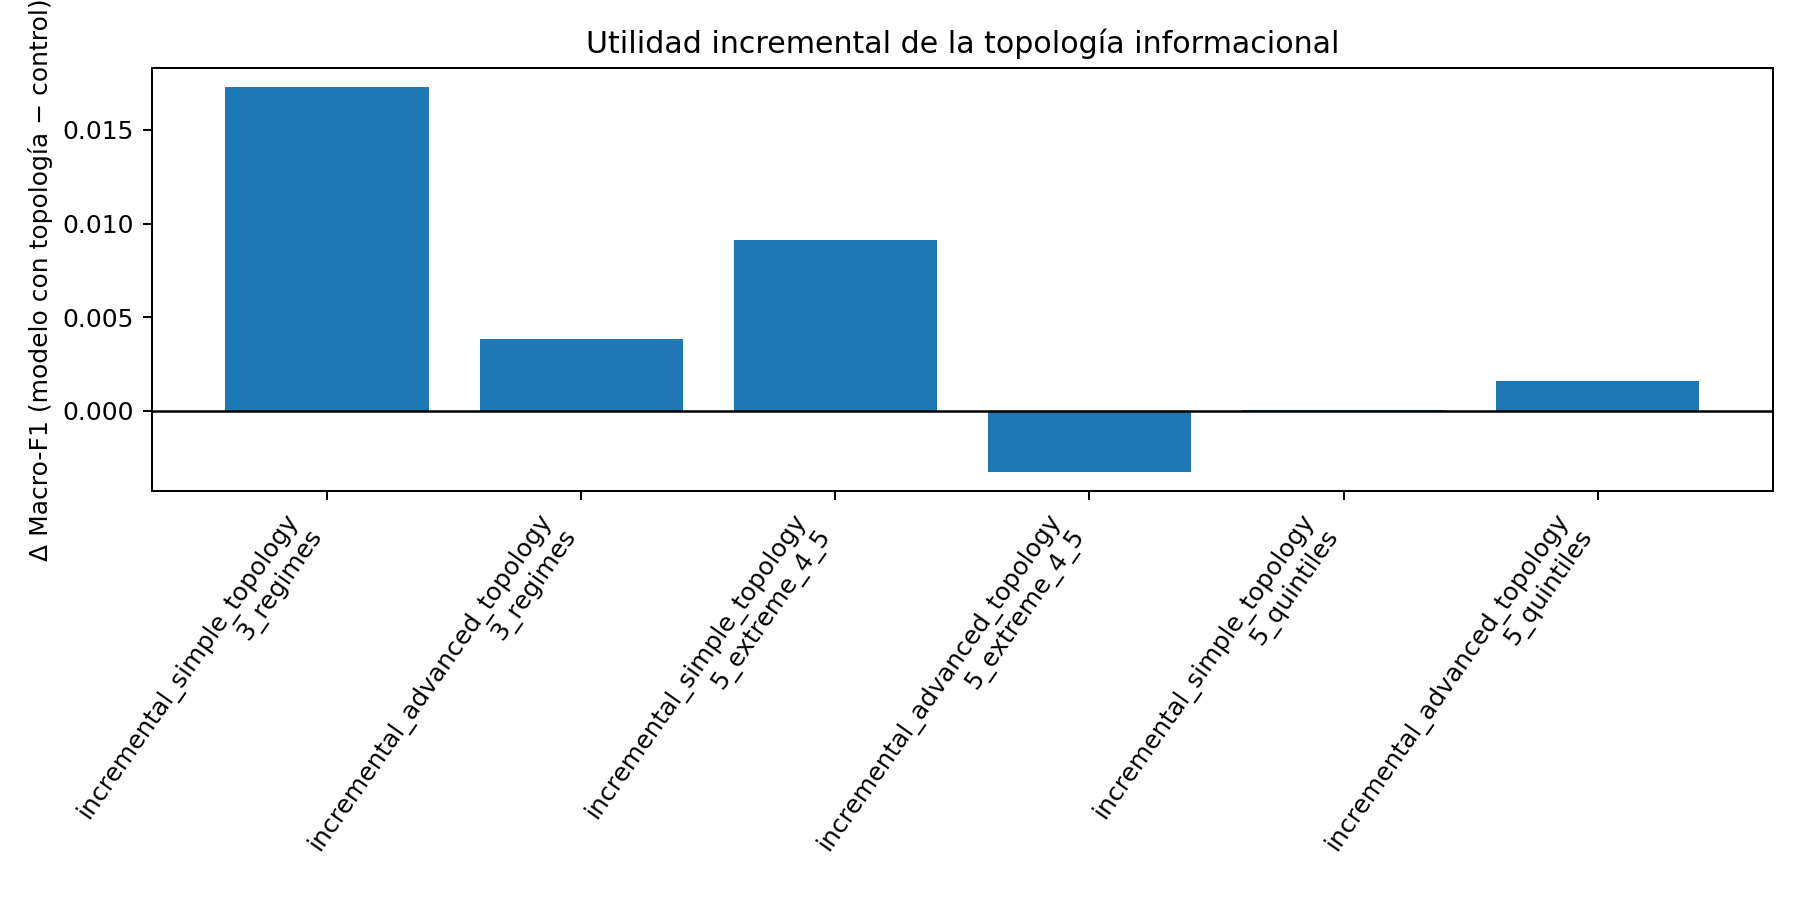

In [ ]:
utility = load_result('13_utilidad_topologia.csv')
utility_summary = load_result('14_resumen_utilidad_topologia.csv')
display(utility.sort_values(['regime_scheme', 'contrast', 'split']))
display(utility_summary)
display(Image(filename=str(OUTPUT_DIR / 'fig_03_utilidad_incremental.png')))

## 16. Lectura científica automática

El bloque resume dirección, magnitud y estabilidad del aporte sin convertir una diferencia predictiva en afirmación causal.

In [ ]:
incremental = utility[utility['contrast'].str.startswith('incremental', na=False)].copy()
holdout_incremental = incremental[incremental['split'] == 'holdout']
walk_incremental = incremental[incremental['split'].str.startswith('fold_')]

print('HOLDOUT — utilidad incremental por esquema')
display(
    holdout_incremental[['regime_scheme', 'contrast', 'model', 'baseline_model',
                         'gain_balanced_accuracy', 'gain_macro_f1',
                         'gain_log_loss', 'relative_gain_macro_f1']]
)

if not walk_incremental.empty:
    stability = (
        walk_incremental.groupby(['regime_scheme', 'contrast'], as_index=False)
        .agg(
            folds=('split', 'count'),
            mean_gain_macro_f1=('gain_macro_f1', 'mean'),
            wins_macro_f1=('gain_macro_f1', lambda x: int((x > 0).sum())),
            mean_gain_log_loss=('gain_log_loss', 'mean'),
        )
    )
    print('WALK-FORWARD — estabilidad temporal')
    display(stability)

print(
    'Interpretación: hay evidencia favorable cuando el gain es positivo en holdout '
    'y se repite en la mayoría de los folds. Esto valida utilidad predictiva '
    'incremental de esta operacionalización de primer orden; no demuestra causalidad.'
)

HOLDOUT — utilidad incremental por esquema


,regime_scheme,contrast,model,baseline_model,gain_balanced_accuracy,gain_macro_f1,gain_log_loss,relative_gain_macro_f1
1,3_regimes,incremental_simple_topology,tree_volatility_plus_topology,tree_volatility,0.013202,0.017275,0.004424,0.038856
2,3_regimes,incremental_advanced_topology,lightgbm_volatility_plus_topology,lightgbm_volatility_multiscale,0.006645,0.003809,0.003768,0.007592
4,5_extreme_4_5,incremental_simple_topology,tree_volatility_plus_topology,tree_volatility,0.009175,0.009105,0.005631,0.036502
5,5_extreme_4_5,incremental_advanced_topology,lightgbm_volatility_plus_topology,lightgbm_volatility_multiscale,-0.000660,-0.003250,-0.003219,-0.011523
7,5_quintiles,incremental_simple_topology,tree_volatility_plus_topology,tree_volatility,0.001661,0.000051,0.002062,0.000192
8,5_quintiles,incremental_advanced_topology,lightgbm_volatility_plus_topology,lightgbm_volatility_multiscale,0.006441,0.001603,0.001238,0.004863


WALK-FORWARD — estabilidad temporal


,regime_scheme,contrast,folds,mean_gain_macro_f1,wins_macro_f1,mean_gain_log_loss
0,3_regimes,incremental_advanced_topology,5,0.003303,3,-0.000537
1,3_regimes,incremental_simple_topology,5,0.008901,3,-0.002032
2,5_extreme_4_5,incremental_advanced_topology,5,0.002319,3,-0.015388
3,5_extreme_4_5,incremental_simple_topology,5,0.019359,4,-0.004783
4,5_quintiles,incremental_advanced_topology,5,-0.005810,0,-0.003840
5,5_quintiles,incremental_simple_topology,5,0.011295,4,-0.004323


Interpretación: hay evidencia favorable cuando el gain es positivo en holdout y se repite en la mayoría de los folds. Esto valida utilidad predictiva incremental de esta operacionalización de primer orden; no demuestra causalidad.


In [ ]:
# Con la evidencia completa desde la Etapa A hasta la K, la síntesis empírica es
# ineludible:

# Rechazo de la Hipótesis Micro: La topología de red ($BTC\_y$)
# no posee poder resolutivo estacionario para predecir fluctuaciones puntuales,
# ni clasificar cuantiles de alta resolución, ni cazar colas extremas. Intentar
# forzar esto mediante hiper-parametrización (LightGBM multiescala) desemboca en
# sobreajuste severo y degradación temporal (Covariate Shift).

# Confirmación de la Hipótesis de Macro-Gating: La topología sí posee información
# intrínseca y  ortogonal a la volatilidad pasada, pero opera exclusivamente como
# un descriptor  inercial de baja frecuencia. Su utilidad predictiva marginal se
# maximiza cuando es destilada por arquitecturas de baja complejidad (árboles poco profundos)
# y se aplica a la partición de regímenes anchos (3 clases), donde actúa como
# un regularizador robusto frente al ruido financiero.Has acorralado
# el comportamiento de la variable. Sabes exactamente qué puede hacer
#  (modular regímenes amplios) y qué no puede hacer (micromanagement predictivo).


## 17. Manifiesto reproducible

Conserva configuración, backend, ventanas, columnas, tamaños muestrales y contrato temporal de la corrida.

In [ ]:
manifest_path = OUTPUT_DIR / 'manifest.json'
with manifest_path.open(encoding='utf-8') as handle:
    manifest = json.load(handle)
display(manifest)

{'source_chat': 'https://chatgpt.com/share/6a9da6eb-5c68-83e9-8b4d-c3c4109c5ff1',
 'scientific_scope': 'Utilidad incremental de la coordenada BTC_y del simplex como descriptor de regímenes futuros de volatilidad; no es una prueba causal del NPP completo.',
 'config': {'price_path': '/content/drive/MyDrive/0626p.parquet',
  'simplex_path': '/content/drive/MyDrive/0626dfyp.parquet',
  'output_dir': '/content/drive/MyDrive/Neural/NPP/Cripto/topologia_informacional_BTC',
  'price_column': 'BTCUSDT',
  'topology_column': 'BTC_y',
  'timestamp_column': None,
  'start_timestamp': '2026-01-01 00:00:00+00:00',
  'frequency': '10min',
  'holdout_fraction': 0.3,
  'future_horizon': 2,
  'past_vol_window': 2,
  'max_lag': 20,
  'volatility_horizons': [1, 2, 3, 6, 12],
  'folds': 5,
  'seed': 42,
  'extreme_tail': 0.045,
  'tree_depth': 4,
  'tree_min_leaf': 250,
  'boosting_iterations': 300,
  'boosting_learning_rate': 0.03,
  'boosting_leaves': 15,
  'boosting_depth': 5,
  'permutation_repeats': 

## 18. Prompts técnicos por modelo

Se genera un prompt autocontenido para cada estimador único. Los benchmarks también se documentan, aclarando que capas, activaciones, optimizador, batch y épocas no aplican. Las métricas se insertan desde los CSV de la corrida actual, no se escriben a mano.

In [ ]:
confusions = load_result('10b_matrices_confusion_holdout.csv')

def compact_table(frame, columns):
    if frame.empty:
        return 'No disponible en esta corrida.'
    existing = [column for column in columns if column in frame.columns]
    table = frame[existing].copy()
    numeric = table.select_dtypes(include='number').columns
    table[numeric] = table[numeric].round(6)
    return table.to_string(index=False)

def architecture_and_optimization(model, family):
    if model == 'persistence':
        return (
            'Benchmark determinista: proyecta sigma_past como sigma_future. No es una red; '
            'no tiene capas, dimensiones, activaciones, Dropout, BatchNorm ni L1/L2.',
            'No se entrena: no hay loss optimizada, optimizador, learning rate, batch size ni épocas.'
        )
    if model.startswith('linear_'):
        return (
            'Regresión lineal OLS de una sola salida, equivalente a una transformación afín '
            'con activación identidad. Sin capas ocultas, Dropout, BatchNorm ni regularización explícita.',
            'Mínimos cuadrados ordinarios de scikit-learn; error cuadrático como criterio implícito. '
            'No usa learning rate, weight decay, batch size ni épocas iterativas.'
        )
    if model.startswith('histgb_') and family == 'regression':
        return (
            'HistGradientBoostingRegressor: ensamble secuencial de árboles histogramados, '
            'max_depth=5 y max_leaf_nodes=15. No usa capas neuronales, activaciones, Dropout o BatchNorm.',
            'Loss squared_error; learning_rate=0.03; max_iter=300; random_state=42. '
            'No existe batch size y no se configuró penalización L1/L2 adicional.'
        )
    if model == 'dummy_most_frequent':
        return (
            'DummyClassifier determinista que siempre pronostica la clase más frecuente de train. '
            'No tiene red, capas, activaciones ni regularización.',
            'No optimiza parámetros: sin loss entrenada, optimizador, learning rate, batch o épocas.'
        )
    if model.startswith('tree_'):
        return (
            'DecisionTreeClassifier CART, max_depth=4 y min_samples_leaf=250. '
            'La profundidad y el mínimo por hoja actúan como regularización estructural; '
            'no hay capas neuronales, activaciones, Dropout ni BatchNorm.',
            'Criterio Gini de scikit-learn; crecimiento voraz del árbol; random_state=42. '
            'No usa optimizador por gradiente, learning rate, batch size ni épocas.'
        )
    if model.startswith('lightgbm_'):
        return (
            'LGBMClassifier multiclase: gradient boosting de 300 árboles, num_leaves=15 y '
            'max_depth=5. La restricción de hojas/profundidad regulariza la complejidad; '
            'no es una red neuronal y no usa Dropout o BatchNorm.',
            'Objective=multiclass con log-loss; learning_rate=0.03; n_estimators=300; '
            'random_state=42; sin L1/L2 explícitos. No existe batch size; cada árbol es una iteración.'
        )
    if model.startswith('histgb_'):
        return (
            'HistGradientBoostingClassifier multiclase: ensamble de árboles histogramados, '
            'max_depth=5 y max_leaf_nodes=15. No es una red neuronal; no usa Dropout o BatchNorm.',
            'Loss log_loss; learning_rate=0.03; max_iter=300; random_state=42. '
            'Sin batch size ni regularización L1/L2 explícita.'
        )
    return ('Arquitectura no reconocida automáticamente.', 'Optimización no reconocida automáticamente.')

def feature_context(feature_set, family):
    descriptions = {
        'sigma_past': 'volatilidad RMS pasada disponible en t',
        'sigma_past+dBTC_y': 'volatilidad pasada más variación contemporánea de la cuota BTC_y',
        'dummy': 'la entrada se ignora; el benchmark usa únicamente la frecuencia de clases de train',
        'simple_volatility': 'sigma_past',
        'simple_topology': 'BTC_y y dBTC_y',
        'simple_combined': 'sigma_past, BTC_y y dBTC_y',
        'advanced_volatility': 'estado multiescala causal de volatilidad: nivel, lags, medias, dispersión y EMA',
        'advanced_topology': 'estado multiescala causal de BTC_y: nivel, cambios, Shannon, logit, lags, rolling y EMA',
        'advanced_combined': 'familias multiescala de volatilidad y BTC_y más interacciones entre ambas',
    }
    task = (
        'regresión de sigma_future a 20 minutos'
        if family == 'regression'
        else 'clasificación temporal de 3 regímenes, 5 regímenes con colas 4.5% y 5 quintiles'
    )
    return (
        f'Problema: {task}. Features: {descriptions.get(feature_set, feature_set)}. '
        'Preprocesamiento: alineación cronológica, transformaciones causales, eliminación explícita '
        'de NaN/inf, holdout final del 30%, purga h=2, sin shuffle y umbrales ajustados sólo en train. '
        'Los árboles no requieren escalado ni codificación one-hot.'
    )

def confusion_text(model):
    selected = confusions[confusions['model'] == model]
    if selected.empty:
        return 'No aplica para regresión o no está disponible.'
    blocks = []
    for scheme, part in selected.groupby('regime_scheme', sort=False):
        matrix = part.pivot(index='true_class', columns='predicted_class', values='count').fillna(0).astype(int)
        blocks.append(f'{scheme}:\n{matrix.to_string()}')
    return '\n\n'.join(blocks)

def build_model_prompt(model, family, feature_set):
    architecture, optimization = architecture_and_optimization(model, family)
    if family == 'regression':
        train_metrics = reg_train[reg_train['model'] == model]
        test_metrics = reg_holdout[reg_holdout['model'] == model]
        wf_train = (reg_walk_train[reg_walk_train['model'] == model]
                    if not reg_walk_train.empty else pd.DataFrame())
        wf_eval = (reg_walk[reg_walk['model'] == model]
                   if not reg_walk.empty else pd.DataFrame())
        metric_columns = ['split', 'MAE', 'RMSE', 'R2', 'n_train', 'n_eval']
        per_class = 'No aplica: el target es continuo.'
        matrices = 'No aplica: es un modelo de regresión.'
    else:
        train_metrics = classification_train[classification_train['model'] == model]
        test_metrics = classification[classification['model'] == model]
        wf_train = (walk_train[walk_train['model'] == model]
                    if not walk_train.empty else pd.DataFrame())
        wf_eval = (walk[walk['model'] == model]
                   if not walk.empty else pd.DataFrame())
        metric_columns = ['regime_scheme', 'split', 'accuracy', 'balanced_accuracy',
                          'macro_f1', 'log_loss', 'n_train', 'n_eval']
        per_class = compact_table(
            by_class[by_class['model'] == model],
            ['regime_scheme', 'class_name', 'precision', 'recall', 'f1', 'support']
        )
        matrices = confusion_text(model)

    if wf_train.empty:
        wf_train_text = 'No disponible: walk-forward no ejecutado.'
        wf_eval_text = 'No disponible: walk-forward no ejecutado.'
    else:
        group_cols = ['regime_scheme'] if family == 'classification' else []
        numeric = (['accuracy', 'balanced_accuracy', 'macro_f1', 'log_loss']
                   if family == 'classification' else ['MAE', 'RMSE', 'R2'])
        if group_cols:
            wf_train_summary = wf_train.groupby(group_cols)[numeric].agg(['mean', 'std']).reset_index()
            wf_eval_summary = wf_eval.groupby(group_cols)[numeric].agg(['mean', 'std']).reset_index()
        else:
            wf_train_summary = wf_train[numeric].agg(['mean', 'std']).T.rename_axis('metric').reset_index()
            wf_eval_summary = wf_eval[numeric].agg(['mean', 'std']).T.rename_axis('metric').reset_index()
        wf_train_text = wf_train_summary.round(6).to_string(index=False)
        wf_eval_text = wf_eval_summary.round(6).to_string(index=False)

    return f'''Actuá como revisor metodológico de modelos predictivos para series temporales financieras.

Analizá el modelo `{model}` sin inventar componentes y usando exclusivamente la ficha y métricas siguientes.

1. ARQUITECTURA
{architecture}

2. OPTIMIZACIÓN
{optimization}

3. MÉTRICAS
Entrenamiento del ajuste final:
{compact_table(train_metrics, metric_columns)}

Holdout cronológico:
{compact_table(test_metrics, metric_columns)}

Train walk-forward, media y desvío:
{wf_train_text}

Validación walk-forward, media y desvío:
{wf_eval_text}

Métricas por clase en holdout:
{per_class}

Matrices de confusión holdout:
{matrices}

4. CONTEXTO DE LOS DATOS
{feature_context(feature_set, family)}

Tarea: redactá una ficha técnica rigurosa; compará train contra validación y test; diagnosticá
posible sobreajuste o subajuste; explicá el equilibrio entre clases; distinguí desempeño
predictivo de causalidad; y cerrá con fortalezas, límites y siguiente prueba recomendada.
Si un campo típico de redes neuronales no aplica, indicá explícitamente por qué.'''

regression_models = reg_holdout[['model', 'feature_set']].drop_duplicates().assign(family='regression')
classification_models = classification[['model', 'feature_set']].drop_duplicates().assign(family='classification')
model_catalog = pd.concat([regression_models, classification_models], ignore_index=True).drop_duplicates(['family', 'model'])
MODEL_PROMPTS = {
    f'{row.family}::{row.model}': build_model_prompt(row.model, row.family, row.feature_set)
    for row in model_catalog.itertuples(index=False)
}

prompt_document = ['# Prompts técnicos por modelo', '']
for number, (model, prompt) in enumerate(MODEL_PROMPTS.items(), start=1):
    prompt_document.extend([f'## {number}. {model}', '', '```text', prompt, '```', ''])
PROMPTS_PATH = OUTPUT_DIR / 'prompts_tecnicos_por_modelo.md'
PROMPTS_PATH.write_text('\n'.join(prompt_document), encoding='utf-8')

print(f'{len(MODEL_PROMPTS)} prompts guardados en: {PROMPTS_PATH}')
display(pd.DataFrame({'model': MODEL_PROMPTS.keys(), 'prompt_chars': [len(p) for p in MODEL_PROMPTS.values()]}))

12 prompts guardados en: /content/drive/MyDrive/Neural/NPP/Cripto/topologia_informacional_BTC/prompts_tecnicos_por_modelo.md


,model,prompt_chars
0,regression::persistence,1917
1,regression::linear_volatility,1999
2,regression::linear_volatility_plus_topology,2039
3,regression::histgb_volatility,1982
4,regression::histgb_volatility_plus_topology,2022
5,classification::dummy_most_frequent,5024
6,classification::tree_volatility,5126
7,classification::tree_topology,5128
8,classification::tree_volatility_plus_topology,5156
9,classification::lightgbm_volatility_multiscale,5229


## 19. Consultar un prompt individual

Reemplazá `MODEL_NAME` por cualquiera de los nombres de la tabla anterior.

In [ ]:
MODEL_NAME = next(iter(MODEL_PROMPTS))
display(Markdown(f'### Prompt: `{MODEL_NAME}`\n\n```text\n{MODEL_PROMPTS[MODEL_NAME]}\n```'))

### Prompt: `regression::persistence`

```text
Actuá como revisor metodológico de modelos predictivos para series temporales financieras.

Analizá el modelo `persistence` sin inventar componentes y usando exclusivamente la ficha y métricas siguientes.

1. ARQUITECTURA
Benchmark determinista: proyecta sigma_past como sigma_future. No es una red; no tiene capas, dimensiones, activaciones, Dropout, BatchNorm ni L1/L2.

2. OPTIMIZACIÓN
No se entrena: no hay loss optimizada, optimizador, learning rate, batch size ni épocas.

3. MÉTRICAS
Entrenamiento del ajuste final:
        split      MAE     RMSE        R2  n_train  n_eval
holdout_train 0.001057 0.001702 -0.185763    18215   18215

Holdout cronológico:
  split      MAE     RMSE        R2  n_train  n_eval
holdout 0.000906 0.001411 -0.177636    18215    7808

Train walk-forward, media y desvío:
metric      mean      std
   MAE  0.001047 0.000172
  RMSE  0.001695 0.000270
    R2 -0.122857 0.131952

Validación walk-forward, media y desvío:
metric      mean      std
   MAE  0.001120 0.000256
  RMSE  0.001747 0.000402
    R2 -0.374382 0.244401

Métricas por clase en holdout:
No aplica: el target es continuo.

Matrices de confusión holdout:
No aplica: es un modelo de regresión.

4. CONTEXTO DE LOS DATOS
Problema: regresión de sigma_future a 20 minutos. Features: volatilidad RMS pasada disponible en t. Preprocesamiento: alineación cronológica, transformaciones causales, eliminación explícita de NaN/inf, holdout final del 30%, purga h=2, sin shuffle y umbrales ajustados sólo en train. Los árboles no requieren escalado ni codificación one-hot.

Tarea: redactá una ficha técnica rigurosa; compará train contra validación y test; diagnosticá
posible sobreajuste o subajuste; explicá el equilibrio entre clases; distinguí desempeño
predictivo de causalidad; y cerrá con fortalezas, límites y siguiente prueba recomendada.
Si un campo típico de redes neuronales no aplica, indicá explícitamente por qué.
```

## Conclusión de alcance

El experimento evalúa si una coordenada informacional del simplex aporta capacidad de identificación de regímenes. Sus variables son componentes NPP de primer orden: accesibles y transferibles, pero todavía sujetos a mejorar con microestructura, volatilidad condicional, liquidez efectiva y mediciones directas de resistencia sistémica.

El uso posterior propuesto es un gate probabilístico de cinco estados: `[P_XL, P_L, P_M, P_H, P_XH]`, no una predicción mecánica de precio.